# 00 — Descarga y panorámica de los datos

> **La base de datos del TFM.** Este notebook documenta y visualiza *todo* lo que se ha
> recopilado para la detección de regímenes: qué series, de dónde, con cuánta historia, y en
> qué estado. La descarga la ejecuta el módulo reproducible `src/ingest/` (dirigido por
> `data/catalog.yaml`); aquí **cargamos el resultado y lo enseñamos**.

## Reglas del juego (echadas a tierra)

- **Máximo dato, todo gratis.** Fuentes verificadas una a una: **FRED** (API con key), **yfinance**,
  **OFR** (índice de estrés), **académico** (Ken French, Shiller) y **github/datahub**.
- **Sin imputar.** Cada serie arranca en su fecha real; los huecos son *fechas ausentes del índice*,
  nunca valores inventados. Los detectores ya alinearán por calendario causal.
- **Dos pistas** (decisión [`ADR-001`](../docs/decisions/ADR-001-rebase-datos.md)):
  **A** = espina histórica profunda (S&P 500 + vol, ~1927+, para tener **22 crisis** → potencia);
  **B** = panel rico multi-activo (crédito/curva/vol/FX/macro, ~1990/2007+, para atacar el
  **punto ciego de 2013**). Algunas series sirven a **ambas**.
- **Procedencia trazable**: `data/raw/provenance.json` (checksum por serie) y
  `data/raw/coverage_report.csv` (inventario). Los `.parquet` crudos están gitignored (pesan);
  los metadatos se versionan.

> Informe de fuentes: [`docs/SOTA_datos.md`](../docs/SOTA_datos.md) · Universo declarado:
> [`data/catalog.yaml`](../data/catalog.yaml) · Análisis: [`01_eda.ipynb`](01_eda.ipynb).

In [1]:
import sys, warnings, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.3,'font.size':9,
                     'axes.spines.top':False,'axes.spines.right':False})

ROOT = Path.cwd()
while not (ROOT/'data'/'catalog.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
import yaml
cov = pd.read_csv(ROOT/'data'/'raw'/'coverage_report.csv')
cov['inicio_dt']=pd.to_datetime(cov['inicio']); cov['fin_dt']=pd.to_datetime(cov['fin'])
cat = yaml.safe_load((ROOT/'data'/'catalog.yaml').read_text(encoding='utf-8'))
DESC={s['nombre_interno']: s.get('descripcion','') for p in ['pista_A','pista_B','validacion_externa'] for s in cat[p]['series']}
REL ={s['nombre_interno']: s.get('relevancia_regimen','') for p in ['pista_A','pista_B','validacion_externa'] for s in cat[p]['series']}
SRC = dict(zip(cov.nombre, cov.fuente))
ok = cov[cov.status.isin(['OK','CACHE'])].copy()
err = cov[cov.status=='ERROR'].copy()
def load(name):
    return pd.read_parquet(ROOT/'data'/'raw'/SRC[name]/f'{name}.parquet')[name].sort_index()
COL={'A':'#2c7fb8','B':'#d95f0e','ambas':'#7b3294','validacion':'#31a354'}
print(f'Series descargadas: {len(ok)} / {len(cov)}   ({len(err)} no disponibles, declaradas)')
print(f'Rango histórico: {ok.inicio_dt.min().date()}  ->  {ok.fin_dt.max().date()}')

Series descargadas: 166 / 174   (8 no disponibles, declaradas)
Rango histórico: 1854-12-01  ->  2026-07-20


## 1. El catálogo de un vistazo

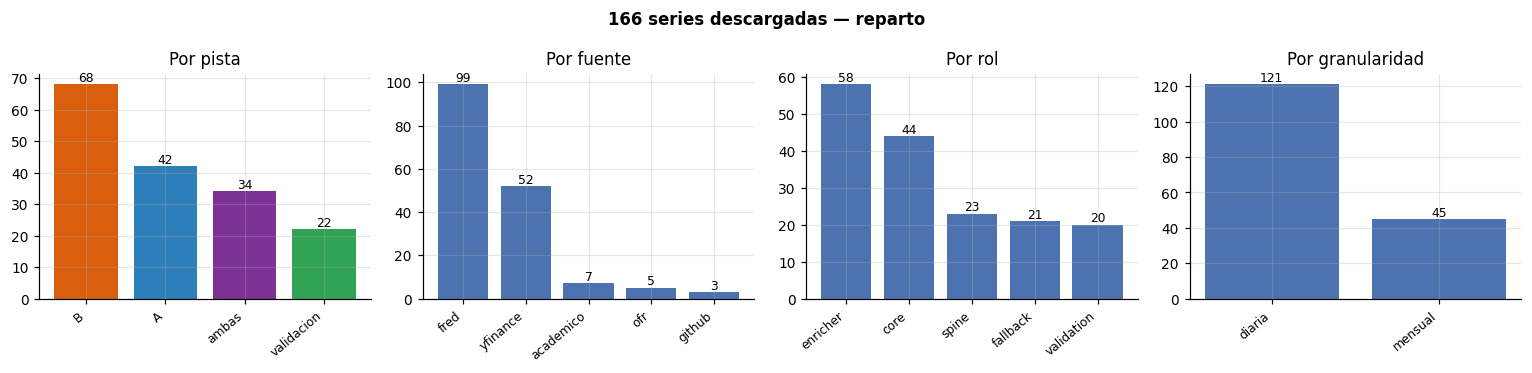

Pistas:  A = espina profunda | B = panel rico | ambas = dual-uso | validacion = ground truth de estres/crisis
Roles:   spine (columna vertebral) > core > enricher > fallback > validation


In [2]:
fig,ax=plt.subplots(1,4,figsize=(14,3.4))
for a,(col,ttl) in zip(ax,[('pista','Por pista'),('fuente','Por fuente'),('rol','Por rol'),('granularidad','Por granularidad')]):
    vc=ok[col].value_counts()
    colors=[COL.get(k,'#888') for k in vc.index] if col=='pista' else '#4c72b0'
    a.bar(range(len(vc)),vc.values,color=colors)
    a.set_xticks(range(len(vc))); a.set_xticklabels(vc.index,rotation=40,ha='right',fontsize=8)
    a.set_title(ttl); [a.text(i,v,str(v),ha='center',va='bottom',fontsize=8) for i,v in enumerate(vc.values)]
fig.suptitle(f'{len(ok)} series descargadas — reparto',fontweight='bold'); plt.tight_layout(); plt.show()
print('Pistas:  A = espina profunda | B = panel rico | ambas = dual-uso | validacion = ground truth de estres/crisis')
print('Roles:   spine (columna vertebral) > core > enricher > fallback > validation')

## 2. Cobertura temporal — ¿cuánta historia tiene cada serie?

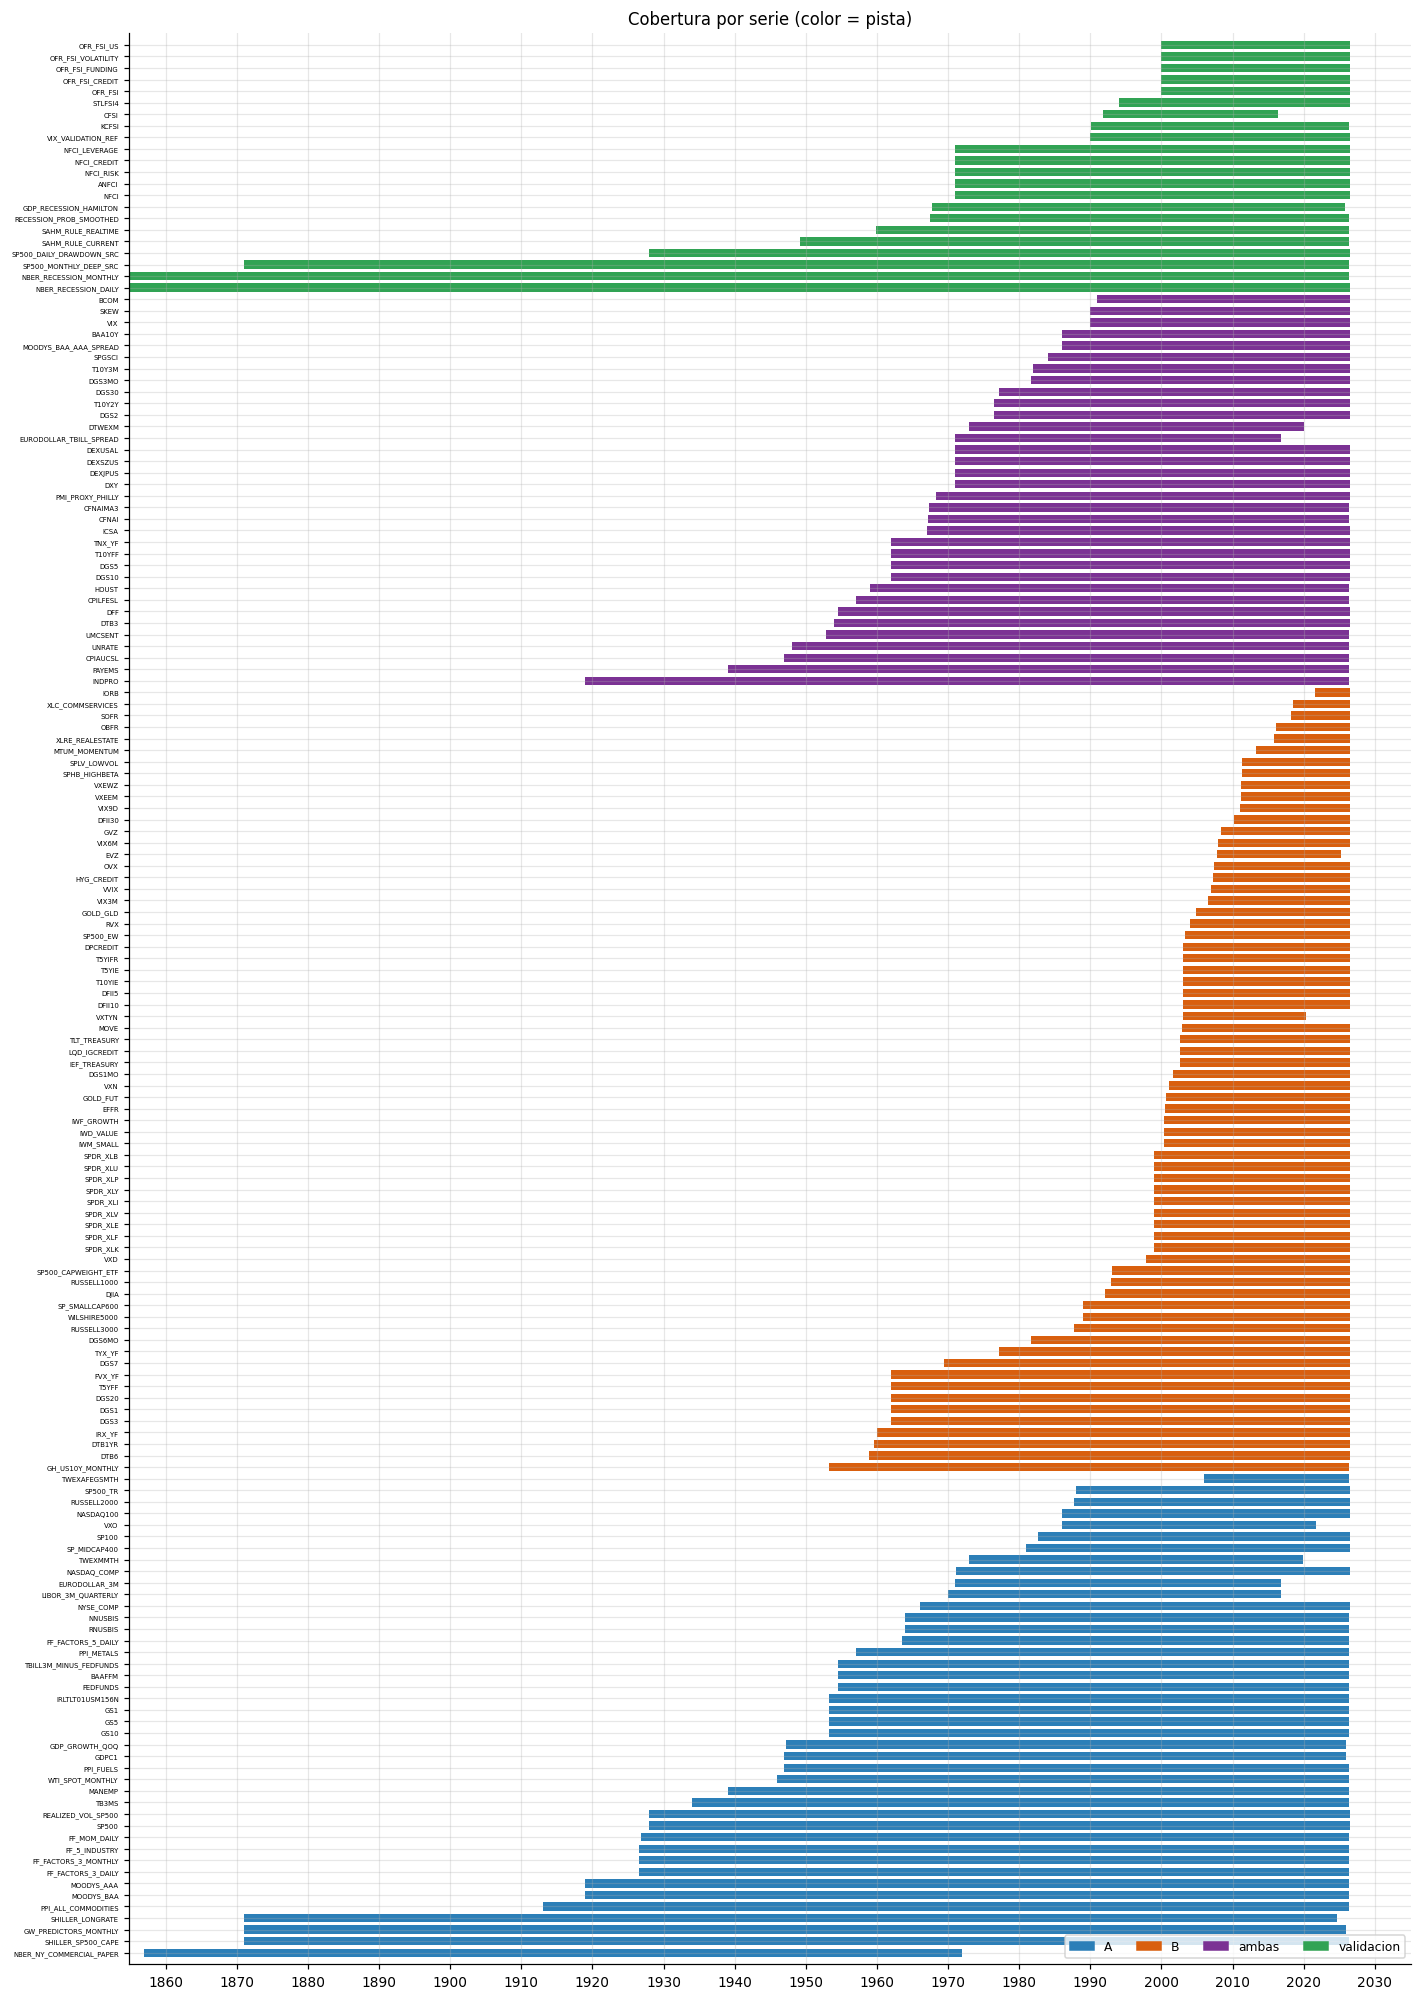

In [3]:
g=ok.sort_values(['pista','inicio_dt'])
fig,ax=plt.subplots(figsize=(13,max(7,len(g)*0.11)))
for i,(_,r) in enumerate(g.iterrows()):
    ax.barh(i,(r['fin_dt']-r['inicio_dt']).days,left=r['inicio_dt'],color=COL.get(r['pista'],'#888'),height=.72)
ax.set_yticks(range(len(g))); ax.set_yticklabels(g['nombre'],fontsize=4.5); ax.set_ylim(-1,len(g))
ax.xaxis.set_major_locator(mdates.YearLocator(10)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(handles=[Patch(color=c,label=p) for p,c in COL.items()],loc='lower right',ncol=4,fontsize=8)
ax.set_title('Cobertura por serie (color = pista)'); ax.grid(axis='x',alpha=.3); plt.tight_layout(); plt.show()

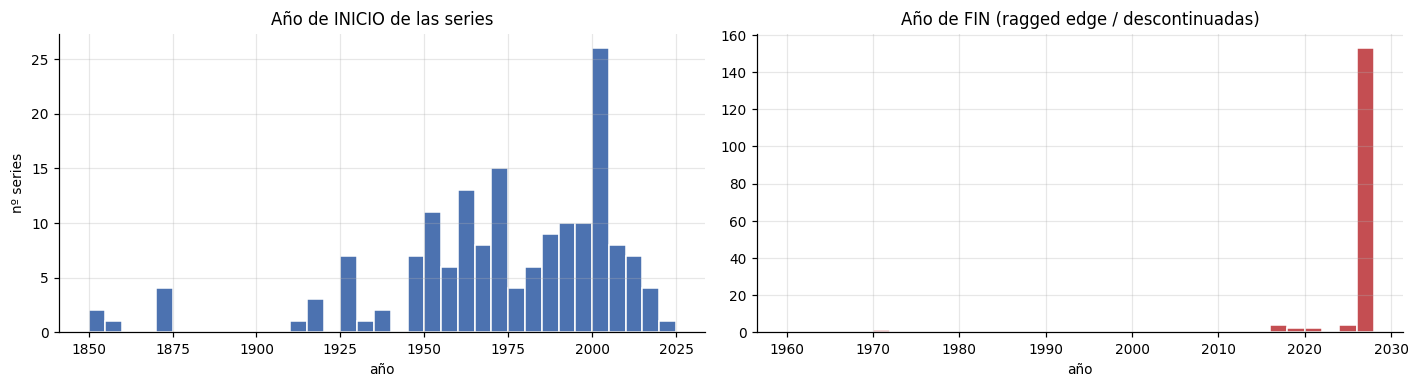

Las 8 series más profundas:
                  nombre    fuente     inicio        fin  n_obs
    NBER_RECESSION_DAILY      fred 1854-12-01 2026-07-05  62674
  NBER_RECESSION_MONTHLY      fred 1854-12-01 2026-06-01   2059
NBER_NY_COMMERCIAL_PAPER      fred 1857-01-01 1971-12-01   1380
      SHILLER_SP500_CAPE    github 1871-01-01 2026-06-01   1866
   GW_PREDICTORS_MONTHLY academico 1871-01-01 2025-12-01   1860
        SHILLER_LONGRATE academico 1871-01-01 2024-09-01   1845
  SP500_MONTHLY_DEEP_SRC    github 1871-01-01 2026-06-01   1866
     PPI_ALL_COMMODITIES      fred 1913-01-01 2026-06-01   1362


In [4]:
fig,ax=plt.subplots(1,2,figsize=(13,3.6))
ax[0].hist(ok.inicio_dt.dt.year,bins=range(1850,2030,5),color='#4c72b0',edgecolor='white')
ax[0].set_title('Año de INICIO de las series'); ax[0].set_xlabel('año'); ax[0].set_ylabel('nº series')
ax[1].hist(ok.fin_dt.dt.year,bins=range(1960,2030,2),color='#c44e52',edgecolor='white')
ax[1].set_title('Año de FIN (ragged edge / descontinuadas)'); ax[1].set_xlabel('año')
plt.tight_layout(); plt.show()
deep=ok.nsmallest(8,'inicio_dt')[['nombre','fuente','inicio','fin','n_obs']]
print('Las 8 series más profundas:'); print(deep.to_string(index=False))

## 3. Tabla completa de lo descargado

Las **166 series**, ordenadas por pista y antigüedad. `n_obs` = observaciones reales (sin imputar).

In [5]:
tab=ok.assign(descripcion=ok.nombre.map(DESC)).sort_values(['pista','inicio_dt'])
tab=tab[['nombre','descripcion','fuente','pista','rol','granularidad','inicio','fin','n_obs']].reset_index(drop=True)
tab['descripcion']=tab['descripcion'].str.slice(0,70)
pd.set_option('display.max_rows',200,'display.max_colwidth',72,'display.width',200)
tab

,nombre,descripcion,fuente,pista,rol,granularidad,inicio,fin,n_obs
0,NBER_NY_COMMERCIAL_PAPER,"Tipo de papel comercial de Nueva York (NBER Macrohistory, mensual). Co",fred,A,spine,mensual,1857-01-01,1971-12-01,1380
1,SHILLER_SP500_CAPE,S&P500 mensual + CAPE (PE10) + Dividend/Earnings/CPI/Long-rate desde 1,github,A,spine,mensual,1871-01-01,2026-06-01,1866
2,GW_PREDICTORS_MONTHLY,"Goyal-Welch predictores del equity premium MENSUALES: Index, D12, E12,",academico,A,core,mensual,1871-01-01,2025-12-01,1860
3,SHILLER_LONGRATE,"Long-term interest rate (10y gov bond) mensual desde 1871, dataset de",academico,A,fallback,mensual,1871-01-01,2024-09-01,1845
4,PPI_ALL_COMMODITIES,Producer Price Index by Commodity: All Commodities (mensual). Precios,fred,A,spine,mensual,1913-01-01,2026-06-01,1362
5,MOODYS_BAA,Moody's Seasoned Baa Corporate Bond Yield (mensual). Yield IG-bajo des,fred,A,spine,mensual,1919-01-01,2026-06-01,1290
6,MOODYS_AAA,Moody's Seasoned Aaa Corporate Bond Yield (mensual). Pata alta calidad,fred,A,spine,mensual,1919-01-01,2026-06-01,1290
7,FF_FACTORS_3_DAILY,"Fama-French 3 factores DIARIOS (Mkt-RF, SMB, HML) + RF, mercado US (CR",academico,A,spine,diaria,1926-07-01,2026-05-29,26253
8,FF_FACTORS_3_MONTHLY,"Fama-French 3 factores MENSUALES (Mkt-RF, SMB, HML) + RF.",academico,A,fallback,mensual,1926-07-01,2026-05-01,1199
9,FF_5_INDUSTRY,"Ken French 5 Industry Portfolios diarios (Cnsmr,Manuf,HiTec,Hlth,Other",academico,A,enricher,diaria,1926-07-01,2026-05-29,26253


## 4. Vistazo a los datos por categoría

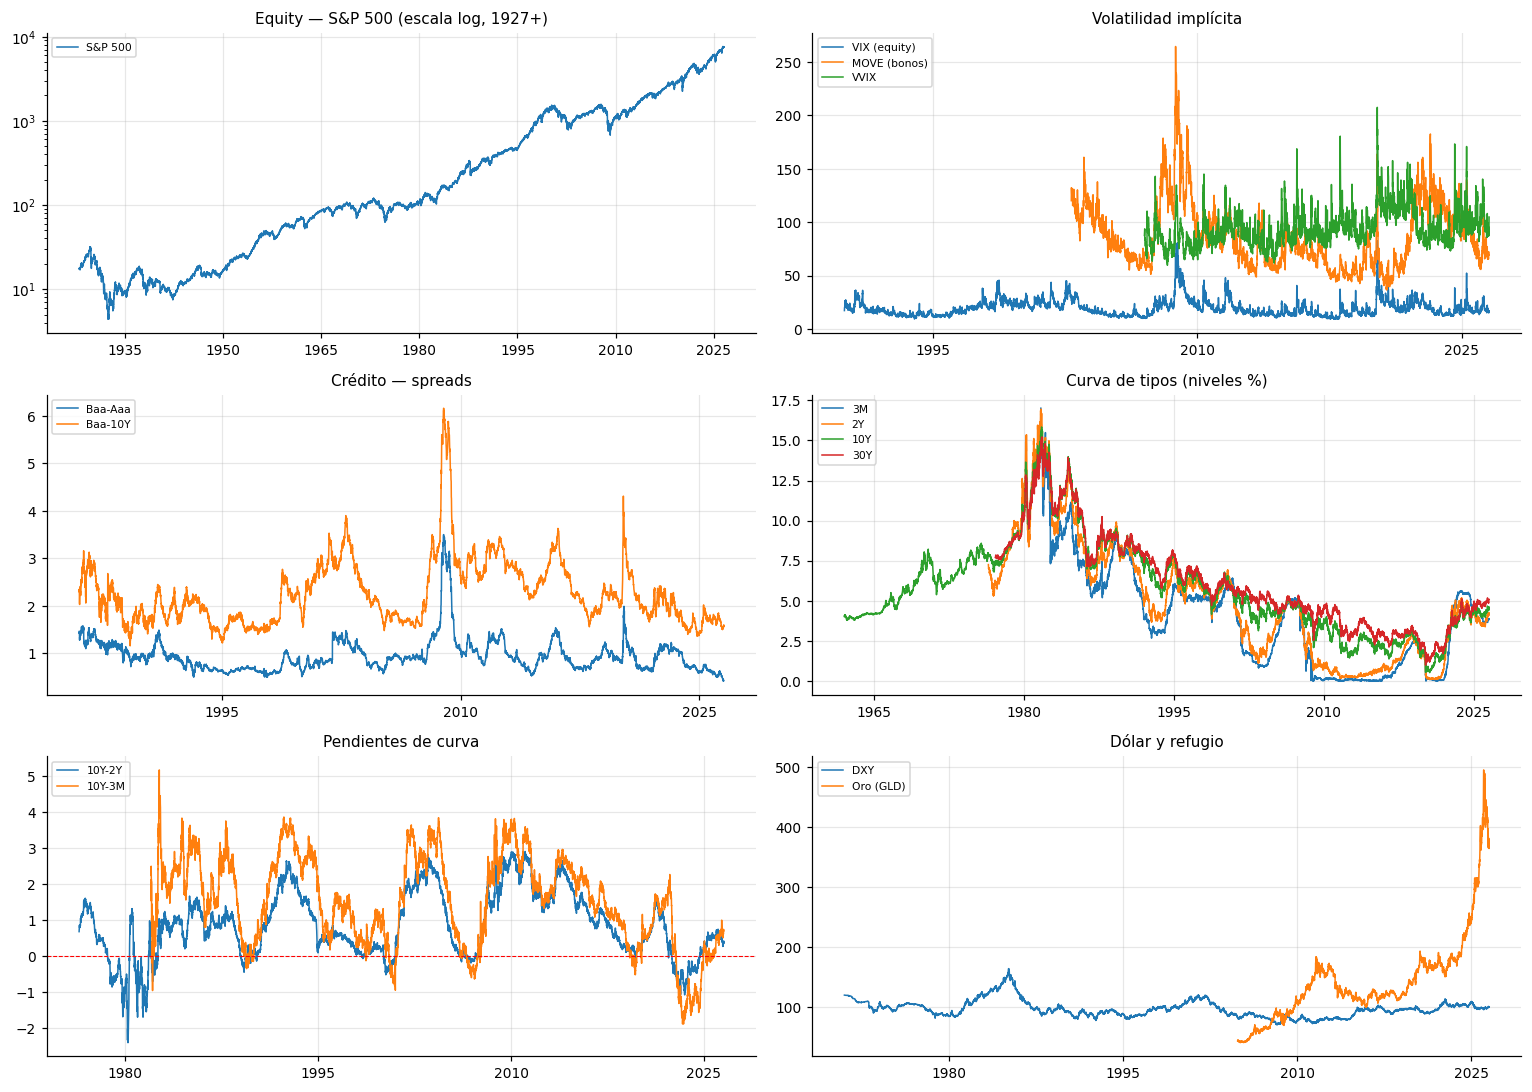

In [6]:
def tryload(n):
    try: return load(n)
    except Exception: return None
panels=[
 ('Equity — S&P 500 (escala log, 1927+)', [('SP500','S&P 500')], True),
 ('Volatilidad implícita', [('VIX','VIX (equity)'),('MOVE','MOVE (bonos)'),('VVIX','VVIX')], False),
 ('Crédito — spreads', [('MOODYS_BAA_AAA_SPREAD','Baa-Aaa'),('BAA10Y','Baa-10Y')], False),
 ('Curva de tipos (niveles %)', [('DGS3MO','3M'),('DGS2','2Y'),('DGS10','10Y'),('DGS30','30Y')], False),
 ('Pendientes de curva', [('T10Y2Y','10Y-2Y'),('T10Y3M','10Y-3M')], False),
 ('Dólar y refugio', [('DXY','DXY'),('GOLD_GLD','Oro (GLD)')], False),
]
fig,axes=plt.subplots(3,2,figsize=(14,10))
for ax,(ttl,series,logy) in zip(axes.ravel(),panels):
    n=0
    for nm,lab in series:
        s=tryload(nm)
        if s is None: continue
        ax.plot(s.index,s.values,label=lab,lw=1); n+=1
    if logy: ax.set_yscale('log')
    ax.set_title(ttl,fontsize=10); ax.legend(fontsize=7,loc='upper left')
    ax.xaxis.set_major_locator(mdates.YearLocator(15)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    if 'Pendientes' in ttl: ax.axhline(0,c='r',ls='--',lw=.7)
plt.tight_layout(); plt.show()

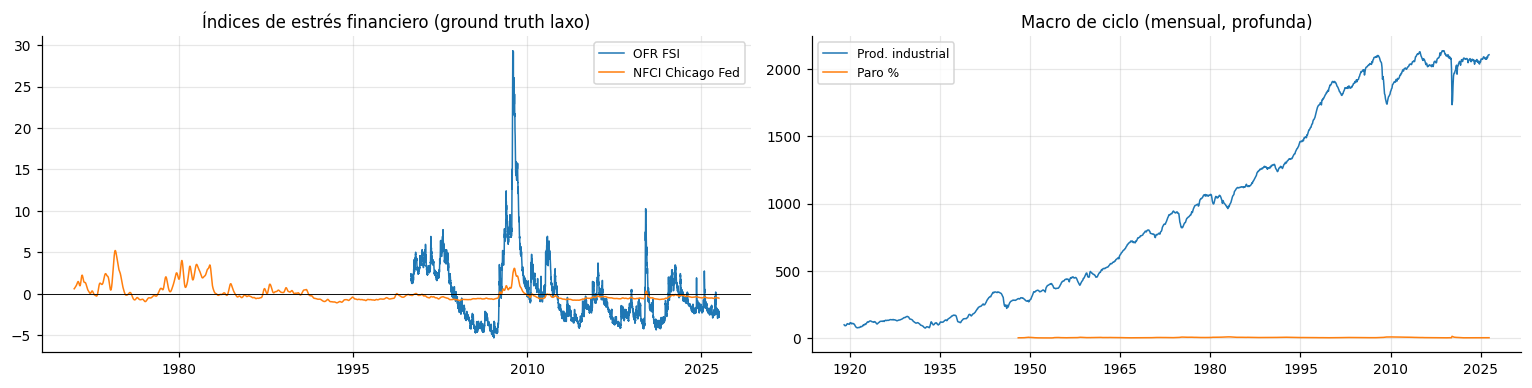

In [7]:
# Índices de estrés (validacion) + macro de ciclo
fig,ax=plt.subplots(1,2,figsize=(14,3.6))
for nm,lab in [('OFR_FSI','OFR FSI'),('NFCI','NFCI Chicago Fed')]:
    s=tryload(nm)
    if s is not None: ax[0].plot(s.index,s.values,label=lab,lw=1)
ax[0].axhline(0,c='k',lw=.6); ax[0].set_title('Índices de estrés financiero (ground truth laxo)'); ax[0].legend(fontsize=8)
for nm,lab in [('INDPRO','Prod. industrial'),('UNRATE','Paro %')]:
    s=tryload(nm)
    if s is not None:
        v=s if lab.endswith('%') else 100*s/s.iloc[0]
        ax[1].plot(v.index,v.values,label=lab,lw=1)
ax[1].set_title('Macro de ciclo (mensual, profunda)'); ax[1].legend(fontsize=8)
for a in ax: a.xaxis.set_major_locator(mdates.YearLocator(15)); a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

## 5. El catálogo de crisis (la etiqueta) — 22 eventos desde 1929

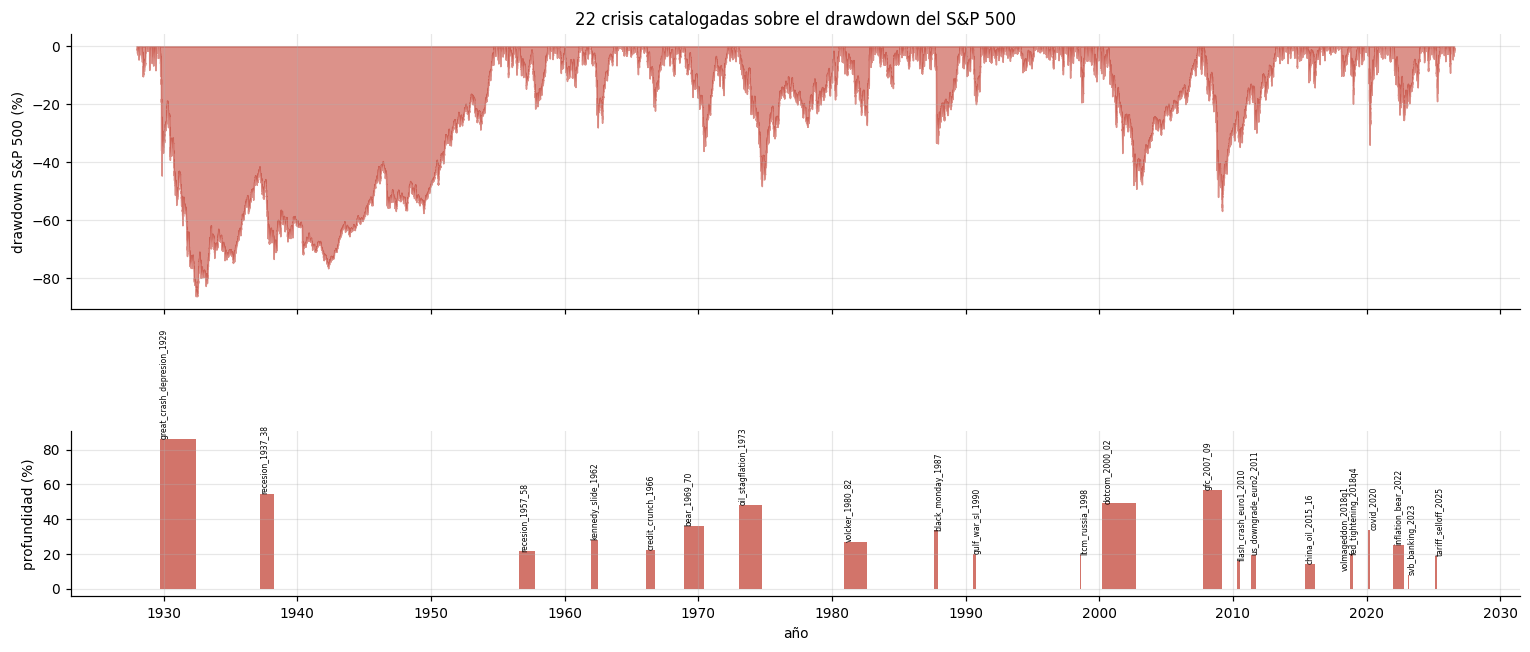

Reparto por tipo: {'bear': 10, 'correction': 7, 'crash': 3, 'vol_spike': 1, 'credit_event': 1}
Recesiones NBER: 10 / 22


In [8]:
ev=pd.DataFrame(cat['crisis_catalog']['eventos'])
ev['peak']=pd.to_datetime(ev['peak']); ev['trough']=pd.to_datetime(ev['trough']); ev=ev.sort_values('peak')
spx=tryload('SP500')
fig,ax=plt.subplots(2,1,figsize=(14,6),height_ratios=[2,1.2],sharex=True)
if spx is not None:
    dd=(spx/spx.cummax()-1)*100
    ax[0].fill_between(dd.index,dd.values,0,color='#c0392b',alpha=.55)
ax[0].set_ylabel('drawdown S&P 500 (%)'); ax[0].set_title(f'{len(ev)} crisis catalogadas sobre el drawdown del S&P 500')
for _,e in ev.iterrows():
    ax[1].barh(0,(e['trough']-e['peak']).days,left=e['peak'],height=abs(e['depth'])*100,align='edge',color='#c0392b',alpha=.7)
    ax[1].text(e['peak'],abs(e['depth'])*100,e['name'],rotation=90,fontsize=5,va='bottom')
ax[1].set_ylabel('profundidad (%)'); ax[1].set_xlabel('año')
ax[1].xaxis.set_major_locator(mdates.YearLocator(10)); ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()
print('Reparto por tipo:', ev['tipo'].value_counts().to_dict())
print('Recesiones NBER:', int(ev['nber'].sum()), '/', len(ev))

## 6. El punto ciego de 2013: **no es falta de datos, es falta de señal**

En julio de 2013 (taper tantrum) el panel estaba **casi entero poblado** — el problema no fue
cobertura sino que fue un shock de *tipos* puro (lo desmenuza [`01_eda.ipynb`](01_eda.ipynb) §4).

In [9]:
d0=pd.Timestamp('2013-07-01')
def has(nm):
    s=tryload(nm)
    return s is not None and (s.index<=d0).any() and (s.index>=d0-pd.Timedelta('7D')).any()
for pst in ['A','B']:
    names=ok[ok.pista.isin([pst,'ambas'])].nombre
    n=sum(has(x) for x in names)
    print(f'  Pista {pst}: {n}/{len(names)} series con dato alrededor del 2013-07-01')

  Pista A: 74/76 series con dato alrededor del 2013-07-01


  Pista B: 97/102 series con dato alrededor del 2013-07-01


## 7. Lo que NO se pudo descargar (declarado, no omitido)

In [10]:
e=err.copy(); e['motivo']=e['error'].str.slice(0,60)
print(f'{len(e)} series no descargables (ninguna es core):')
print(e[['nombre','fuente','rol','motivo']].to_string(index=False))

8 series no descargables (ninguna es core):
                   nombre    fuente        rol                                                       motivo
  GW_PREDICTORS_QUARTERLY academico   enricher            DateParseError: year 18711 is out of range: 18711
      JST_MACROHISTORY_R6 academico   enricher             RuntimeError: JST macrohistory xlsx no accesible
           DOW_STOOQ_DEEP     stooq   fallback RuntimeError: stooq bloqueado por challenge JS (proof-of-wor
GH_SP500_CONSTITUENTS_PIT    github   enricher RuntimeError: github fja05680/sp500:S&P 500 Historical Compo
GH_SP500_CONSTITUENTS_NOW    github   enricher RuntimeError: github datasets/s-and-p-500-companies:data/con
     PHILLY_ANXIOUS_INDEX academico   fallback ValueError: Excel file format cannot be determined, you must
   JST_CRISIS_GROUNDTRUTH academico validation             RuntimeError: JST macrohistory xlsx no accesible
     SP500_STOOQ_FALLBACK     stooq   fallback RuntimeError: stooq bloqueado por challenge J

**Por qué ninguna es un problema de dato:**
- **stooq** (×2): bloqueadas por su *challenge* JavaScript; son *fallbacks* redundantes (ya tenemos
  `^GSPC` desde 1927 y `^DJI`).
- **constituyentes S&P 500** (×2): son *listas* de componentes, no series temporales.
- **JST macrohistory** (×2): la URL de descarga rotó; las crisis profundas ya están en `crisis_catalog` + NBER.
- **Goyal-Welch quarterly** y **Philly anxious**: redundantes con la versión mensual / con las
  probabilidades de recesión ya descargadas.

## 8. Cierre

- **166/174 series** en `data/raw/<fuente>/<serie>.parquet` (gitignored), **sin imputar**, con
  `provenance.json` (checksum + procedencia) y `coverage_report.csv` versionados.
- **Profundidad**: desde **1854** (NBER) / **1871** (Shiller) / **1913-1919** (macro/crédito) / **1927**
  (S&P 500 diario) → la Pista A ve **22 crisis** (2.2× el panel de 2007).
- **Siguiente**: el análisis vive en [`01_eda.ipynb`](01_eda.ipynb) y el banco congelado en
  [`data/benchmark_spec.yaml`](../data/benchmark_spec.yaml).

*Para re-descargar desde cero:* `python -m src.ingest.download` (idempotente, cacheado).